In [1]:
import numpy as np
import scipy.stats as sps
import glob
import pickle
import json
import sys
import re

import torch
from torch_geometric.data import Data as PYGData, Batch as PYGBatch
from torch.distributions.transforms import AffineTransform
from ili.utils.ndes_pt import LampeEnsemble
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage

import matplotlib.pyplot as plt
import ili
import ili.utils.distributions_pt as dpt

2026-05-01 21:45:00.886842: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777686301.476031  216445 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777686301.629062  216445 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-01 21:45:03.024076: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
sys.path.insert(0, '/home/puehlengt/ltu-ili/notebooks/ambe_fits')
from train_hybrid5_deepset_uniformg1 import (
    Hybrid5DeepSet, PyGBatchWrapper, GraphData, make_summary,
    load_dataset_from_hdf5, build_prior_from_json,
)

In [3]:
SAVE_BASE = '3_param_trained_models/deepset_uniformg1'
#fchkpt    = '500totalsamples_hybrid5_deepset_uniformg1proposal_nsf_h32_t3_emb_hs32_hl2_lr0.0003_CosineAnnealingLR'
fchkpt    = '50000totalsamples_hybrid5_deepset_uniformg1proposal_nsf_h32_t3_emb_hs32_hl2_lr0.0003_CosineAnnealingLR'

TRAIN_HDF5     = '/home/puehlengt/appletree/notebooks/3_params_uniform_g1/training_set/harvested_training.h5'
TEST_HDF5      = '/home/puehlengt/appletree/notebooks/3_params_uniform_g1/test_set/harvested_test.h5'
TRAIN_PRIOR_JSON = '/home/puehlengt/appletree/notebooks/3_params_uniform_g1/training_set/prior_harvested_training.json'
TEST_PRIOR_JSON  = '/home/puehlengt/appletree/notebooks/3_params_uniform_g1/test_set/prior_harvested_test.json'

NUM_TRAIN = int(re.search(r'^(\d+)totalsamples', fchkpt).group(1))
N_OBS     = 1000
DEVICE    = 'cpu'

MODE         = 'checkpoint'  # 'final' or 'checkpoint'
SELECT_EPOCH = 320            # only used if MODE == 'checkpoint'

out_dir = f'{SAVE_BASE}/{fchkpt}'
print(f'out_dir: {out_dir}')

out_dir: 3_param_trained_models/deepset_uniformg1/50000totalsamples_hybrid5_deepset_uniformg1proposal_nsf_h32_t3_emb_hs32_hl2_lr0.0003_CosineAnnealingLR


In [4]:
from ili.utils.ndes_pt import LampeNPE

_hs = int(re.search(r'hs(\d+)', fchkpt).group(1))
_hl = int(re.search(r'hl(\d+)', fchkpt).group(1))
_hf = int(re.search(r'_h(\d+)_', fchkpt).group(1))
_nt = int(re.search(r'_t(\d+)_', fchkpt).group(1))
print(f'Arch: hs={_hs}, hl={_hl}, hidden_features={_hf}, num_transforms={_nt}')

with open(f'{out_dir}/norm_stats.pkl', 'rb') as f:
    norm_stats = pickle.load(f)

_theta_transform = AffineTransform(
    loc=norm_stats['theta_mean'], scale=norm_stats['theta_std'], event_dim=1)

# inference prior (tight Gaussian g1) — used to build the model
_prior = build_prior_from_json(TEST_PRIOR_JSON, device=DEVICE)

_embedding = Hybrid5DeepSet(
    in_channels=2, hidden_layers=_hl, hidden_channels=_hs, out_channels=8)

# dummy batch to let load_nde_lampe infer embedding output dim
_dummy_pyg   = PYGData(x=torch.zeros(10, 2), y=torch.zeros(1, 3), summary=torch.zeros(1, 5))
_dummy_batch = PyGBatchWrapper(PYGBatch.from_data_list([_dummy_pyg]))
_dummy_loader = [(_dummy_batch, torch.zeros(1, 3))]

_factory = ili.utils.load_nde_lampe(
    model='nsf', hidden_features=_hf, num_transforms=_nt,
    embedding_net=_embedding, x_normalize=False, theta_normalize=False)[0]
base_model = _factory(_dummy_loader, _prior)
base_model.theta_transform = _theta_transform

if MODE == 'final':
    with open(f'{out_dir}/posterior.pkl', 'rb') as f:
        ensemble = pickle.load(f)
    base_model = ensemble.posteriors[0]
    print(f'Loaded final model from {out_dir}/posterior.pkl')
else:
    path_bag = glob.glob(f'{out_dir}/checkpoint_epoch*.pt')
    path_bag.sort(key=lambda p: int(re.search(r'epoch(\d+)', p).group(1)))
    epochs_available = [int(re.search(r'epoch(\d+)', p).group(1)) for p in path_bag]
    print('Available epochs:', epochs_available)

    ckpt_path = path_bag[epochs_available.index(SELECT_EPOCH)]
    base_model.load_state_dict(torch.load(ckpt_path, map_location='cpu', weights_only=True))
    print(f'Loaded checkpoint epoch {SELECT_EPOCH}: {ckpt_path}')

base_model.eval()

Arch: hs=32, hl=2, hidden_features=32, num_transforms=3
Available epochs: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320]
Loaded checkpoint epoch 320: 3_param_trained_models/deepset_uniformg1/50000totalsamples_hybrid5_deepset_uniformg1proposal_nsf_h32_t3_emb_hs32_hl2_lr0.0003_CosineAnnealingLR/checkpoint_epoch320.pt


LampeNPE(
  (nde): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [0, 1, 2]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=16, out_features=32, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=32, out_features=32, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=32, out_features=69, bias=True)
          )
        )
        (1): MaskedAutoregressiveTransform(
          (base): MonotonicRQSTransform(bins=8)
          (order): [2, 1, 0]
          (hyper): MaskedMLP(
            (0): MaskedLinear(in_features=16, out_features=32, bias=True)
            (1): ReLU()
            (2): MaskedLinear(in_features=32, out_features=32, bias=True)
            (3): ReLU()
            (4): MaskedLinear(in_features=32, out_features=69, bias=True)
          )
        )
        (2): MaskedAutoregressi

In [5]:
raw_test, param_names = load_dataset_from_hdf5(TEST_HDF5, N_OBS)
print(f'param order: {param_names}')

all_summaries_test = np.stack([make_summary(d) for d in raw_test])
summary_norm_test  = torch.tensor(
    (all_summaries_test - norm_stats['summary_mean']) / norm_stats['summary_std'],
    dtype=torch.float32
)
test_graph = GraphData(raw_test, norm_stats['events_mean'], norm_stats['events_std'], summary_norm_test)
theta_test = np.array([d.y.numpy().flatten() for d in raw_test])

# load a slice of training thetas for the histogram overlay
_train_raw, _ = load_dataset_from_hdf5(TRAIN_HDF5, NUM_TRAIN)
theta_train    = np.array([d.y.numpy().flatten() for d in _train_raw])
print(f'train={theta_train.shape}, test={theta_test.shape}')

param order: ['g1', 'g2', 'ambe_nr_rate']
train=(50000, 3), test=(1000, 3)


In [6]:
posterior = LampeEnsemble(posteriors=[base_model], weights=torch.tensor([1.0]))

## Marginal posteriors

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 7038.13it/s]


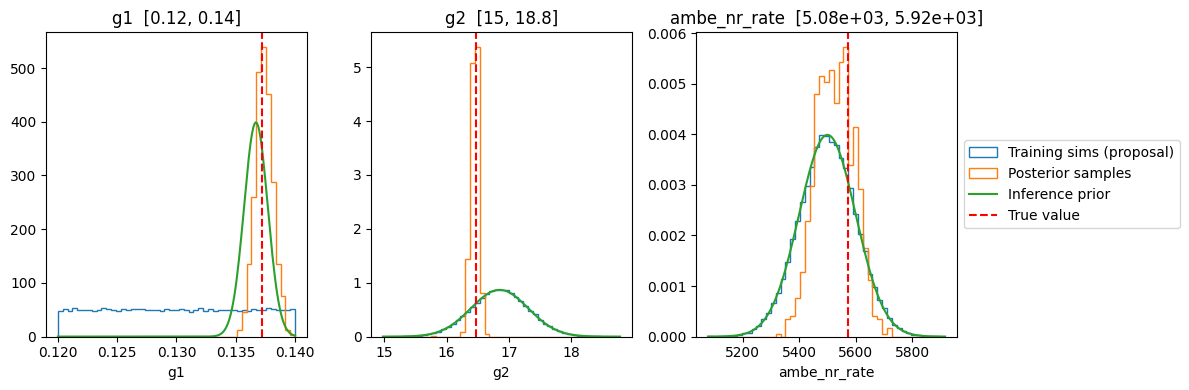

In [7]:
OBS_IDX = 0

x_obs  = test_graph[OBS_IDX]
y_true = theta_test[OBS_IDX]

# load prior/proposal specs for overlay
with open(TEST_PRIOR_JSON)  as f: prior_cfg    = json.load(f)
with open(TRAIN_PRIOR_JSON) as f: proposal_cfg = json.load(f)

torch.manual_seed(1234)
samples = posterior.sample((1000,), x_obs).cpu().numpy()

n_params = len(param_names)
fig, axes = plt.subplots(1, n_params, figsize=(n_params * 4, 4))

for ii, key in enumerate(param_names):
    ax = axes[ii]
    zzz = theta_train[:, ii]
    zzmin, zzmax = zzz.min(), zzz.max()
    bins = np.linspace(zzmin, zzmax, 50)

    ax.hist(zzz,          bins=bins, density=True, histtype='step', label='Training sims (proposal)')
    ax.hist(samples[:, ii], bins=bins, density=True, histtype='step', label='Posterior samples')

    # prior PDF overlay
    pspec = prior_cfg[key]
    if pspec['prior_type'] == 'norm':
        xx = np.linspace(zzmin, zzmax, 200)
        ax.plot(xx, sps.truncnorm.pdf(
            xx,
            a=(pspec['allowed_range'][0] - pspec['prior_args']['mean']) / pspec['prior_args']['std'],
            b=(pspec['allowed_range'][1] - pspec['prior_args']['mean']) / pspec['prior_args']['std'],
            loc=pspec['prior_args']['mean'], scale=pspec['prior_args']['std'],
        ), label='Inference prior')
    elif pspec['prior_type'] == 'uniform':
        ax.axhline(1 / (pspec['prior_args']['upper'] - pspec['prior_args']['lower']),
                   linestyle='--', label='Inference prior (uniform)')

    ax.axvline(y_true[ii], color='red', linestyle='--', label='True value')
    ax.set_title(f'{key}  [{zzmin:.3g}, {zzmax:.3g}]')
    ax.set_xlabel(key)

axes[-1].legend(loc='center left', bbox_to_anchor=(1., 0.5))
plt.tight_layout()
fig.savefig(f'{out_dir}/marginals_obs{OBS_IDX}.png', dpi=150, bbox_inches='tight')
plt.show()

## PlotSinglePosterior

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 30319.25it/s]
INFO:root:Saving single posterior plot to 3_param_trained_models/deepset_uniformg1/50000totalsamples_hybrid5_deepset_uniformg1proposal_nsf_h32_t3_emb_hs32_hl2_lr0.0003_CosineAnnealingLR/plot_single_posterior.jpg...


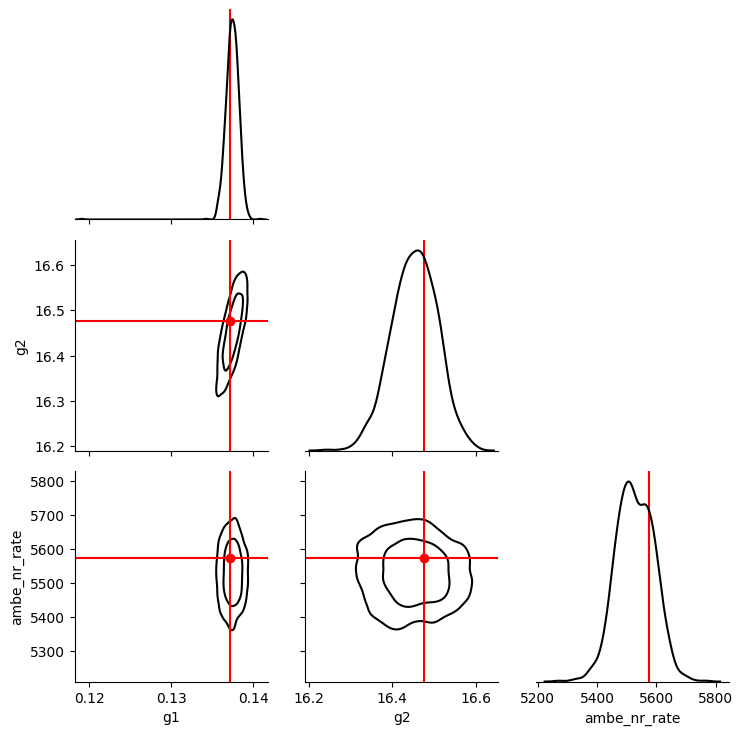

In [8]:
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=param_names, out_dir=out_dir,
)
fig = metric(posterior=posterior, x_obs=x_obs, theta_fid=y_true)

## PosteriorCoverage

100%|██████████| 1000/1000 [00:52<00:00, 19.09it/s]
INFO:root:Saving coverage plot to 3_param_trained_models/deepset_uniformg1/50000totalsamples_hybrid5_deepset_uniformg1proposal_nsf_h32_t3_emb_hs32_hl2_lr0.0003_CosineAnnealingLR/plot_coverage.jpg...
INFO:root:Saving ranks histogram to 3_param_trained_models/deepset_uniformg1/50000totalsamples_hybrid5_deepset_uniformg1proposal_nsf_h32_t3_emb_hs32_hl2_lr0.0003_CosineAnnealingLR/ranks_histogram.jpg...
100%|██████████| 100/100 [00:13<00:00,  7.52it/s]


[<Figure size 1200x400 with 3 Axes>,
 <Figure size 900x400 with 3 Axes>,
 <Figure size 1200x400 with 3 Axes>,
 <Figure size 400x400 with 1 Axes>]

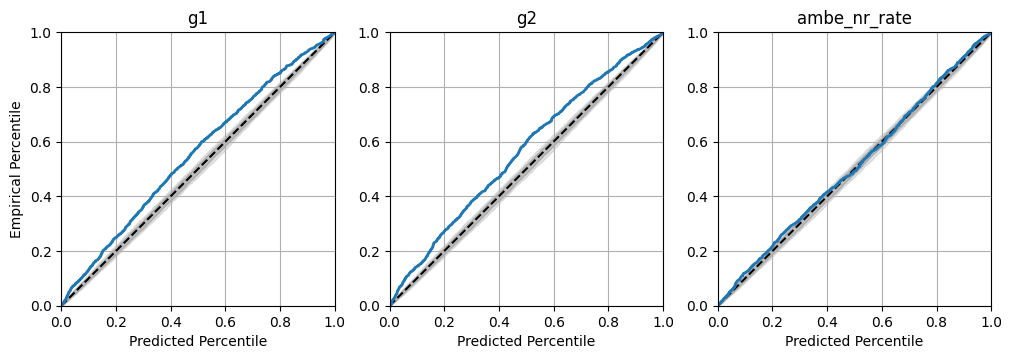

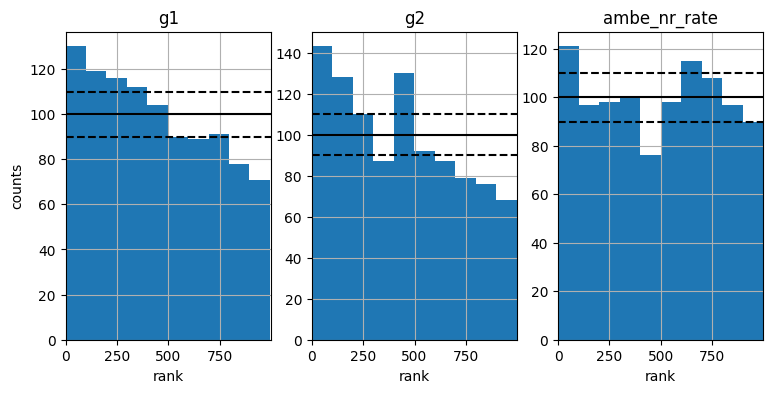

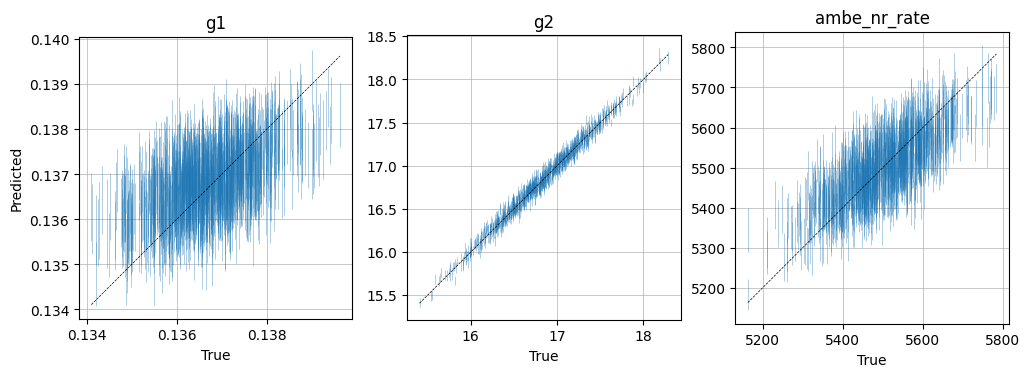

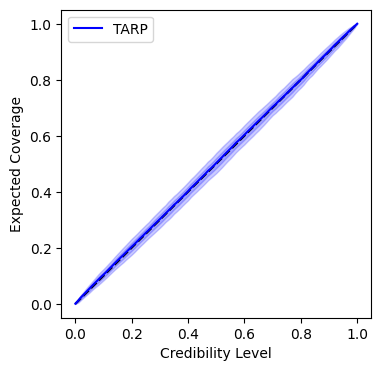

In [9]:
metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=out_dir, labels=param_names,
    plot_list=['coverage', 'predictions', 'tarp', 'histogram'],
    save_samples=False,
)
metric(posterior=posterior, x=test_graph, theta=theta_test)